In [ ]:
# 1. TEMEL KÜTÜPHANELER
import numpy as np               # Sayısal ve matris işlemleri için
import pandas as pd              # Veri analizi ve manipülasyonu için
import matplotlib.pyplot as plt  # Grafik ve görselleştirme için
import seaborn as sns            # Gelişmiş görselleştirme için

# 2. MACHINE LEARNING / SCIKIT-LEARN ARAÇLARI
from sklearn.model_selection import train_test_split, GridSearchCV # Veri bölme ve parametre arama
from sklearn.preprocessing import StandardScaler                   # Özellik ölçekleme
from sklearn.linear_model import LogisticRegression                # Doğrusal sınıflandırma modeli
from sklearn.tree import DecisionTreeClassifier                    # Ağaç tabanlı sınıflandırma modeli
from sklearn.metrics import (                                      # Model başarı metrikleri
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)

# Visual ayarlar
%matplotlib inline
sns.set_theme(style="whitegrid")

# Veriyi Yükleme
df = pd.read_csv("students_data.csv")

# Verinin ilk 5 satırına ve genel yapısına bakalım
print("--- Veri Seti İlk 5 Satır ---")
display(df.head())

print("\n--- Veri Tipleri ve Eksik Değer Kontrolü ---")
print(df.info())

--- Veri Seti İlk 5 Satır ---


,Student_Name,Age,Gender,Course,Attendance,Assignment_Score,Midterm_Score,Final_Score
0,Alice,24,Female,AI/ML,85.0,90.0,80.0,85.0
1,Bob,22,Male,Data Science,62.0,55.0,60.0,58.0
2,Charlie,21,Male,AI/ML,90.0,95.0,88.0,92.0
3,David,23,Male,Web Dev,45.0,50.0,40.0,42.0
4,Emma,26,Female,AI/ML,70.0,NaN,65.0,60.0



--- Veri Tipleri ve Eksik Değer Kontrolü ---
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student_Name      30 non-null     str    
 1   Age               30 non-null     int64  
 2   Gender            30 non-null     str    
 3   Course            30 non-null     str    
 4   Attendance        30 non-null     float64
 5   Assignment_Score  29 non-null     float64
 6   Midterm_Score     29 non-null     float64
 7   Final_Score       30 non-null     float64
dtypes: float64(4), int64(1), str(3)
memory usage: 2.5 KB
None


In [13]:
# 1. EKSİK DEĞERLERİ DOLDURMA (Data Cleaning)
numerical_cols = df.select_dtypes(include=[np.number]).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())

# 2. FEATURE ENGINEERING (Yeni Anlamlı Özellikler Türetme)
# Mevcut sütun isimlerini kontrol ediyoruz
available_cols = list(df.columns)

# a) Ağırlıklı Ders Başarı Puanı
if all(col in available_cols for col in ['Homework', 'Midterm', 'Final']):
    df['Weighted_Score'] = (df['Homework'] * 0.20) + (df['Midterm'] * 0.30) + (df['Final'] * 0.50)
    target_score_col = 'Weighted_Score'
elif 'Overall_Score' in available_cols:
    target_score_col = 'Overall_Score'
else:
    # Eğer yukarıdakiler yoksa sayısal sütunların ortalamasını alarak dinamik skor türetiyoruz
    score_cols = [c for c in numerical_cols if c not in ['Student_ID', 'Attendance']]
    df['Dynamic_Score'] = df[score_cols].mean(axis=1)
    target_score_col = 'Dynamic_Score'

# b) Çalışma Saati / Devamsızlık Oranı
if 'Study_Hours' in available_cols and 'Attendance' in available_cols:
    df['Study_per_Attendance'] = df['Study_Hours'] / (df['Attendance'] + 1e-5)

# 3. HEDEF DEĞİŞKENİ (Passed) OLUŞTURMA
# Belirlenen skor kolonu üzerinden 50 barajıyla Passed (1/0) oluşturulur
df['Passed'] = (df[target_score_col] >= 50).astype(int)

print(f"Hedef değişken '{target_score_col}' sütunu kullanılarak oluşturuldu!")
display(df.head())

Hedef değişken 'Dynamic_Score' sütunu kullanılarak oluşturuldu!


,Student_Name,Age,Gender,Course,Attendance,Assignment_Score,Midterm_Score,Final_Score,Dynamic_Score,Passed
0,Alice,24,Female,AI/ML,85.0,90.000000,80.0,85.0,69.750000,1
1,Bob,22,Male,Data Science,62.0,55.000000,60.0,58.0,48.750000,0
2,Charlie,21,Male,AI/ML,90.0,95.000000,88.0,92.0,74.000000,1
3,David,23,Male,Web Dev,45.0,50.000000,40.0,42.0,38.750000,0
4,Emma,26,Female,AI/ML,70.0,74.206897,65.0,60.0,56.301724,1


In [14]:
# 1. GEREKSİZ/SAYISAL OLMAYAN SÜTUNLARI ÇIKARMA
# İsim, ID gibi benzersiz metinler tahmin gücü taşımaz, overfit (ezber) yaptırır.
cols_to_drop = ['Student_ID', 'Name', 'Passed'] # 'Passed' hedefimiz olduğu için X'ten çıkaracağız

# Eğer Target oluştururken kullandığımız ham notlar varsa onları da veri sızıntısı (Data Leakage) olmasın diye çıkarabiliriz
# Çünkü Passed değişkenini zaten bu notlardan türettik!
if 'Passed' in df.columns:
    X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
    y = df['Passed']

# 2. KATEGORİK DEĞİŞKENLERİ SAYISALA ÇEVİRME (One-Hot Encoding)
# Örn: Course sütununda 'AI/ML', 'Cyber Security' yazıyorsa bunları 0 ve 1'lere çeviriyoruz.
X = pd.get_dummies(X, drop_first=True)

print("--- Modeli Besleyeceğimiz Özellikler (X) ---")
print("Özellik Sayısı:", X.shape[1])
print("Özellik İsimleri:", list(X.columns))

--- Modeli Besleyeceğimiz Özellikler (X) ---
Özellik Sayısı: 39
Özellik İsimleri: ['Age', 'Attendance', 'Assignment_Score', 'Midterm_Score', 'Final_Score', 'Dynamic_Score', 'Student_Name_Arthur', 'Student_Name_Bella', 'Student_Name_Bob', 'Student_Name_Charlie', 'Student_Name_Chris', 'Student_Name_David', 'Student_Name_Diana', 'Student_Name_Emma', 'Student_Name_Frank', 'Student_Name_Grace', 'Student_Name_Hannah', 'Student_Name_Ian', 'Student_Name_Jack', 'Student_Name_Karen', 'Student_Name_Liam', 'Student_Name_Mia', 'Student_Name_Noah', 'Student_Name_Olivia', 'Student_Name_Peter', 'Student_Name_Quinn', 'Student_Name_Rachel', 'Student_Name_Sam', 'Student_Name_Tina', 'Student_Name_Umar', 'Student_Name_Victor', 'Student_Name_Wendy', 'Student_Name_Xavier', 'Student_Name_Yara', 'Student_Name_Zack', 'Gender_Male', 'Course_Cyber Security', 'Course_Data Science', 'Course_Web Dev']


In [15]:
# ADIM 4: TRAIN-TEST SPLIT VE FEATURE SCALING

# 1. TRAIN - TEST SPLIT (%80 Eğitim, %20 Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2. FEATURE SCALING (StandardScaler)
scaler = StandardScaler()

# Train setini fit edip ölçeklendiriyoruz
X_train_scaled = scaler.fit_transform(X_train)

# Test setini sadece transform ediyoruz
X_test_scaled = scaler.transform(X_test)

print("✅ Değişkenler başarıyla tanımlandı!")
print("X_train_scaled şekli:", X_train_scaled.shape)

✅ Değişkenler başarıyla tanımlandı!
X_train_scaled şekli: (24, 39)


In [16]:
# 1. BASELINE LOGISTIC REGRESSION
baseline_lr = LogisticRegression(random_state=42)
baseline_lr.fit(X_train_scaled, y_train)
y_pred_base_lr = baseline_lr.predict(X_test_scaled)
y_prob_base_lr = baseline_lr.predict_proba(X_test_scaled)[:, 1] # ROC-AUC için 1 olma olasılığı

# Metrikleri Hesaplama
base_acc = accuracy_score(y_test, y_pred_base_lr)
base_f1 = f1_score(y_test, y_pred_base_lr, zero_division=0)
base_auc = roc_auc_score(y_test, y_prob_base_lr)

print(f"--- Baseline Logistic Regression ---")
print(f"Accuracy : {base_acc:.4f}")
print(f"F1 Score : {base_f1:.4f}")
print(f"ROC-AUC  : {base_auc:.4f}")

--- Baseline Logistic Regression ---
Accuracy : 1.0000
F1 Score : 1.0000
ROC-AUC  : 1.0000


In [17]:
# 1. ARANACAK HİPERPARAMETRE IZGARASI (Param Grid)
# C: Regülasyon gücü (Küçük C = Güçlü ceza/Basit model, Büyük C = Az ceza/Karmaşık model)
# penalty: Ceza türü (l1: Lasso, l2: Ridge)
# solver: İyileştirme algoritması
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] # liblinear hem l1 hem l2 cezasını destekler
}

# 2. GRIDSEARCHCV MODELİNİ KURMA
# estimator: Optimize edilecek model
# param_grid: Denediğimiz parametreler
# cv=5: Veriyi 5 parçaya bölüp çapraz doğrulama yapar
# scoring='f1': En iyi modeli neye göre seçecek? (f1, accuracy, roc_auc)
grid_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1',
    n_jobs=-1 # Tüm CPU çekirdeklerini kullanır
)

# 3. ARAMAYI BAŞLATMA (Eğitim)
grid_lr.fit(X_train_scaled, y_train)

# 4. EN İYİ SONUÇLARI YAZDIRMA
print("--- GridSearchCV Sonuçları ---")
print("En İyi Parametreler:", grid_lr.best_params_)
print("En İyi CV F1 Skoru :", grid_lr.best_score_)

# En iyi modeli seçip tahmin alma
best_lr_model = grid_lr.best_estimator_
y_pred_tuned_lr = best_lr_model.predict(X_test_scaled)
y_prob_tuned_lr = best_lr_model.predict_proba(X_test_scaled)[:, 1]

--- GridSearchCV Sonuçları ---
En İyi Parametreler: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
En İyi CV F1 Skoru : 0.9206349206349206


c:\Users\aysenur\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\aysenur\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [18]:
# Tuned Model Metrikleri
tuned_acc = accuracy_score(y_test, y_pred_tuned_lr)
tuned_prec = precision_score(y_test, y_pred_tuned_lr, zero_division=0)
tuned_rec = recall_score(y_test, y_pred_tuned_lr, zero_division=0)
tuned_f1 = f1_score(y_test, y_pred_tuned_lr, zero_division=0)
tuned_auc = roc_auc_score(y_test, y_prob_tuned_lr)

# Baseline Model Detaylı Metrikleri
base_prec = precision_score(y_test, y_pred_base_lr, zero_division=0)
base_rec = recall_score(y_test, y_pred_base_lr, zero_division=0)

# ÖZET TABLOSU (DataFrame)
results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Baseline Model': [base_acc, base_prec, base_rec, base_f1, base_auc],
    'Tuned Model (GridSearchCV)': [tuned_acc, tuned_prec, tuned_rec, tuned_f1, tuned_auc]
})

display(results_df)

,Metric,Baseline Model,Tuned Model (GridSearchCV)
0,Accuracy,1.0,1.0
1,Precision,1.0,1.0
2,Recall,1.0,1.0
3,F1-Score,1.0,1.0
4,ROC-AUC,1.0,1.0


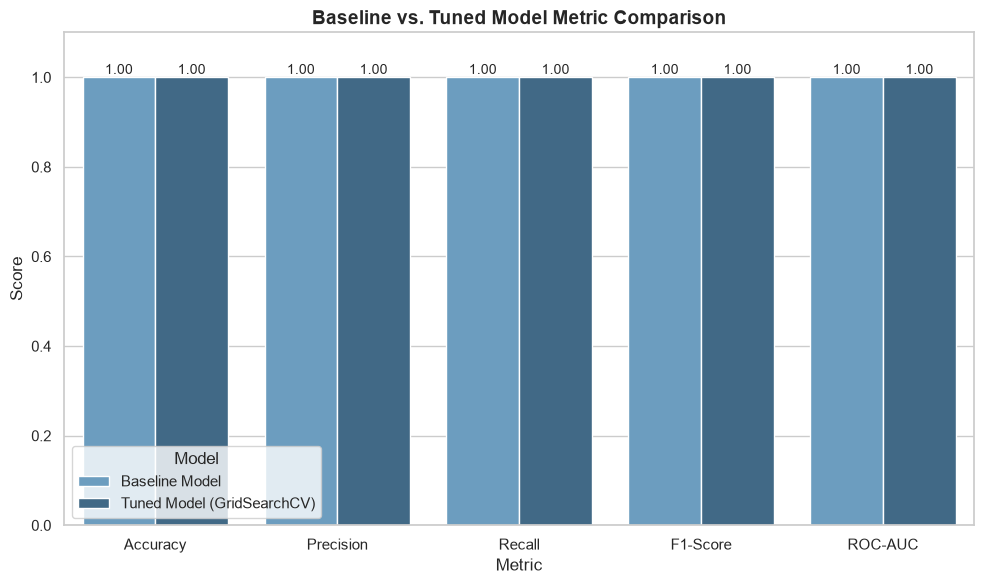

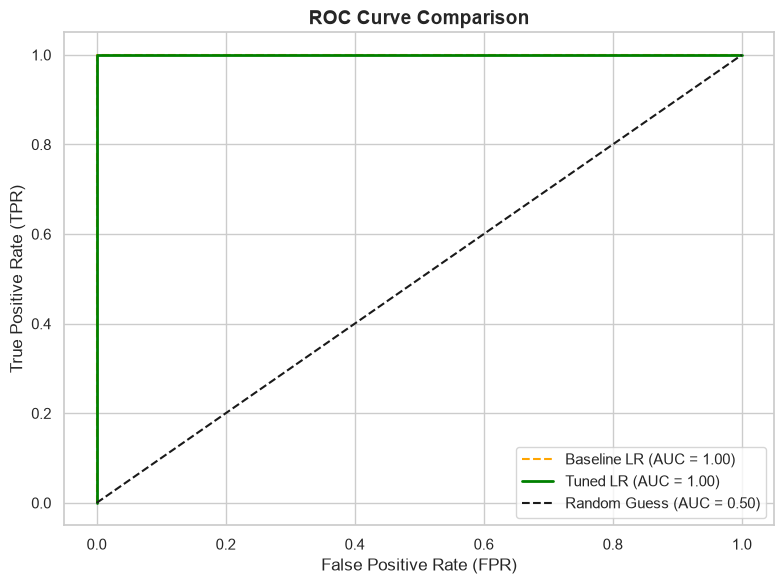

In [19]:
# 1. METRİK KARŞILAŞTIRMA BARI (Bar Chart)
fig, ax = plt.subplots(figsize=(10, 6))

df_melted = pd.melt(results_df, id_vars=['Metric'], var_name='Model', value_name='Score')
sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette='Blues_d', ax=ax)

ax.set_ylim(0, 1.1)
ax.set_title("Baseline vs. Tuned Model Metric Comparison", fontsize=14, fontweight='bold')
ax.set_ylabel("Score")

# Barların üzerine sayısal değerleri yazma
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.2f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.savefig("chart_model_comparison.png", dpi=300) # Kaydediyoruz
plt.show()

# 2. ROC CURVE EĞRİSİ (ROC-AUC Comparison)
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base_lr)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_prob_tuned_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_base, tpr_base, label=f'Baseline LR (AUC = {base_auc:.2f})', color='orange', linestyle='--')
plt.plot(fpr_tuned, tpr_tuned, label=f'Tuned LR (AUC = {tuned_auc:.2f})', color='green', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)') # Şans çizgisi

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True)

plt.tight_layout()
plt.savefig("chart_roc_curve.png", dpi=300) # Kaydediyoruz
plt.show()